# Optimización mediante Pruning y Compresión Ligera para la Ejecución Eficiente de Modelos de IA en Dispositivos de Borde para Entornos IoT con Recursos Limitados, 2026

**Modelo principal:** LightGBM  
**Dataset:** ML-EdgeIIoT-dataset  
**Variable objetivo:** `Attack_type`  

---

## Descripción del Proyecto

Este notebook implementa un **pipeline experimental comparativo** para evaluar estrategias de optimización de modelos de Machine Learning orientados a su despliegue en dispositivos de borde (*edge devices*) con recursos computacionales limitados, en el contexto de redes IoT industriales.

### Estrategias evaluadas:
| # | Estrategia | Descripción |
|---|---|---|
| 1 | **Modelo Base** | LightGBM sin optimización |
| 2 | **Pruning** | Reducción de características por importancia |
| 3 | **Compresión ligera** | Serialización comprimida del modelo para reducción de almacenamiento |
| 4 | **Pruning + Compresión ligera** | Combinación de reducción de características y compresión del modelo |

### Métricas evaluadas:
- Accuracy, Precision, Recall, F1-Score
- Latencia de inferencia (ms)
- Uso de RAM (MB)
- Tamaño del modelo serializado (KB)

## 0. Instalación de Dependencias

Instalación de librerías necesarias para el entorno de Google Colab.

In [1]:
# =============================================================================
# INSTALACIÓN DE DEPENDENCIAS
# =============================================================================
import subprocess, sys

packages = ["lightgbm", "psutil", "joblib"]
for pkg in packages:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("Todas las dependencias están disponibles.")

Todas las dependencias están disponibles.


## 1. Importación de Librerías

Carga de todas las librerías necesarias para el pipeline experimental.

In [2]:
# =============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# =============================================================================

# --- Manipulación de datos ---
import pandas as pd
import numpy as np

# --- Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report
)
import lightgbm as lgb

# --- Serialización y persistencia ---
import joblib
import os
import io
import copy
import struct

# --- Monitoreo de recursos ---
import psutil
import time
import gc

# --- Visualización ---
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# --- Configuración general ---
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# --- Estilo de gráficos ---
plt.style.use("seaborn-v0_8-whitegrid")
matplotlib.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 120
})

print(f" Librerías cargadas correctamente.")
print(f" LightGBM: v{lgb.__version__}")
print(f" Pandas: v{pd.__version__}")
print(f" NumPy: v{np.__version__}")

 Librerías cargadas correctamente.
 LightGBM: v4.6.0
 Pandas: v2.2.2
 NumPy: v2.0.2


## 2. Configuración Global del Pipeline

Parámetros centralizados que gobiernan todo el experimento. Modificar aquí para ajustar el comportamiento global.

In [3]:
# =============================================================================
# CONFIGURACIÓN GLOBAL DEL PIPELINE
# Centraliza todos los hiperparámetros y rutas del experimento
# =============================================================================

CONFIG = {
    # --- Rutas de datos ---
    "dataset_path": "ML-EdgeIIoT-dataset.csv", # Ruta al dataset
    "output_dir": "./output_models", # Directorio de salida para modelos y resultados

    # --- Variable objetivo ---
    "target_col": "Attack_type",

    # --- División del dataset ---
    "test_size": 0.2,
    "random_state": 42,

    # --- Hiperparámetros LightGBM base ---
    "lgbm_params": {
        "objective": "multiclass",
        "metric": "multi_logloss",
        "n_estimators": 200,
        "num_leaves": 63,
        "max_depth": -1,
        "learning_rate": 0.05,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "min_child_samples": 20,
        "reg_alpha": 0.1,
        "reg_lambda": 0.1,
        "verbose": -1,
        "random_state": 42,
        "n_jobs": -1,
    },

    # --- Pruning: top-N características a conservar ---
    "pruning_top_k": 20, # Número de features a retener tras pruning

    # --- Compresión ligera: nivel de compresión Joblib ---
    "compression_level": 9, # Nivel de compresión de 0 a 9

    # --- Inferencia: número de muestras para medir latencia ---
    "latency_samples": 1000,
    "latency_repeats": 5, # Repeticiones para estabilizar la medición
}

# Crear directorio de salida si no existe
os.makedirs(CONFIG["output_dir"], exist_ok=True)

print("Configuración global establecida:")
for k, v in CONFIG.items():
    if k != "lgbm_params":
        print(f"{k}: {v}")
print(f"lgbm_params: {len(CONFIG['lgbm_params'])} parámetros configurados")

Configuración global establecida:
dataset_path: ML-EdgeIIoT-dataset.csv
output_dir: ./output_models
target_col: Attack_type
test_size: 0.2
random_state: 42
pruning_top_k: 20
compression_level: 9
latency_samples: 1000
latency_repeats: 5
lgbm_params: 15 parámetros configurados


In [4]:
from google.colab import files
uploaded = files.upload()

Saving ML-EdgeIIoT-dataset.csv to ML-EdgeIIoT-dataset (1).csv


In [4]:
import os
print(os.listdir())

['.config', 'output_models', 'ML-EdgeIIoT-dataset (1).csv', 'ML-EdgeIIoT-dataset.csv', 'sample_data']


## 3. Carga y Validación del Dataset

Carga del archivo CSV, validación de la variable objetivo y verificación del estado del preprocesamiento previo. Se asume que las columnas no numéricas (excepto `Attack_type`) ya fueron eliminadas.

In [5]:
# =============================================================================
# CARGA Y VALIDACIÓN DEL DATASET
# =============================================================================

df_raw = pd.read_csv(CONFIG["dataset_path"], low_memory=False)
print(f"Forma original: {df_raw.shape}")

# --- Verificar que la columna target existe ---
assert CONFIG["target_col"] in df_raw.columns, \
    f"ERROR: La columna '{CONFIG['target_col']}' no se encontró en el dataset."

# Eliminar posible data leakage
if "Attack_label" in df_raw.columns:
    df_raw = df_raw.drop(columns=["Attack_label"])
    print("Columna Attack_label eliminada para evitar data leakage.")

# --- Separar features y target ---
y_raw = df_raw[CONFIG["target_col"]].copy()
X_raw = df_raw.drop(columns=[CONFIG["target_col"]])

# --- Eliminar columnas no numéricas restantes (por seguridad) ---
non_numeric = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"Eliminando columnas no numéricas detectadas: {non_numeric}")
    X_raw = X_raw.drop(columns=non_numeric)
else:
    print("Todas las columnas de features son numéricas.")

# --- Manejo de valores nulos ---
null_count = X_raw.isnull().sum().sum()
if null_count > 0:
    print(f"Imputando {null_count} valores nulos con la mediana.")
    X_raw = X_raw.fillna(X_raw.median())
else:
    print(f"Sin valores nulos detectados.")

# --- Reemplazar infinitos si existen ---
X_raw = X_raw.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"\nResumen del dataset:")
print(f"Features disponibles: {X_raw.shape[1]}")
print(f"Muestras totales: {X_raw.shape[0]:,}")
print(f"Clases en target: {y_raw.nunique()} → {sorted(y_raw.unique()[:5])}{'...' if y_raw.nunique()>5 else ''}")

Forma original: (157800, 63)
Columna Attack_label eliminada para evitar data leakage.
Eliminando columnas no numéricas detectadas: ['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4', 'arp.src.proto_ipv4', 'http.file_data', 'http.request.uri.query', 'http.request.method', 'http.referer', 'http.request.full_uri', 'http.request.version', 'tcp.options', 'tcp.payload', 'tcp.srcport', 'dns.qry.name.len', 'mqtt.conack.flags', 'mqtt.msg', 'mqtt.protoname', 'mqtt.topic']
Sin valores nulos detectados.

Resumen del dataset:
Features disponibles: 42
Muestras totales: 157,800
Clases en target: 15 → ['Fingerprinting', 'MITM', 'Ransomware', 'SQL_injection', 'Uploading']...


## 4. Preprocesamiento Final

Codificación de la variable objetivo con `LabelEncoder` y división estratificada del dataset en conjuntos de entrenamiento y prueba.

In [6]:
# =============================================================================
# PREPROCESAMIENTO FINAL: LabelEncoder + train_test_split
# =============================================================================

# --- LabelEncoder sobre la variable objetivo ---
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

# Guardar mapeo de clases para referencia
class_mapping = dict(zip(le.transform(le.classes_), le.classes_))
n_classes = len(le.classes_)

print(f"LabelEncoder aplicado sobre '{CONFIG['target_col']}':")
print(f"   Clases codificadas ({n_classes}):")
for code, name in sorted(class_mapping.items()):
    count = (y_encoded == code).sum()
    pct = count / len(y_encoded) * 100
    print(f"[{code:>2}] {name:<30}: {count:>7,} muestras ({pct:5.2f}%)")

# Actualizar parámetros LightGBM con número de clases
CONFIG["lgbm_params"]["num_class"] = n_classes

# --- División estratificada train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X_raw.values, y_encoded,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y_encoded
)

feature_names = X_raw.columns.tolist()

print(f"\nDivisión del dataset:")
print(f"Entrenamiento: {X_train.shape[0]:>7,} muestras y {X_train.shape[1]} features")
print(f"Prueba: {X_test.shape[0]:>7,} muestras y {X_test.shape[1]} features")

LabelEncoder aplicado sobre 'Attack_type':
   Clases codificadas (15):
[ 0] Backdoor                      :  10,195 muestras ( 6.46%)
[ 1] DDoS_HTTP                     :  10,561 muestras ( 6.69%)
[ 2] DDoS_ICMP                     :  14,090 muestras ( 8.93%)
[ 3] DDoS_TCP                      :  10,247 muestras ( 6.49%)
[ 4] DDoS_UDP                      :  14,498 muestras ( 9.19%)
[ 5] Fingerprinting                :   1,001 muestras ( 0.63%)
[ 6] MITM                          :   1,214 muestras ( 0.77%)
[ 7] Normal                        :  24,301 muestras (15.40%)
[ 8] Password                      :   9,989 muestras ( 6.33%)
[ 9] Port_Scanning                 :  10,071 muestras ( 6.38%)
[10] Ransomware                    :  10,925 muestras ( 6.92%)
[11] SQL_injection                 :  10,311 muestras ( 6.53%)
[12] Uploading                     :  10,269 muestras ( 6.51%)
[13] Vulnerability_scanner         :  10,076 muestras ( 6.39%)
[14] XSS                           :  10,052 mu

## 5. Funciones Utilitarias del Pipeline

Módulo de funciones reutilizables para evaluación de modelos, medición de recursos y serialización. El diseño modular facilita la extensión del pipeline.

In [7]:
# =============================================================================
# MÓDULO DE FUNCIONES UTILITARIAS
# =============================================================================

def get_ram_usage_mb() -> float:
    """
    Retorna el uso actual de memoria RAM del proceso en MB.
    Utiliza psutil para una medición precisa a nivel de proceso.
    """
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 2)


def measure_latency_ms(model, X_sample: np.ndarray,
                        n_samples: int = 1000, repeats: int = 5) -> float:
    """
    Mide la latencia de inferencia promedio en milisegundos.

    Realiza múltiples repeticiones y descarta la primera (warm-up)
    para obtener una estimación estable del tiempo de inferencia.

    Args:
        model: Modelo LightGBM entrenado.
        X_sample: Array de features para inferencia.
        n_samples: Número de muestras a procesar por repetición.
        repeats: Número de repeticiones para el promedio.

    Returns:
        Latencia promedio en ms (excluyendo warm-up).
    """
    # Limitar muestras al tamaño disponible
    n = min(n_samples, X_sample.shape[0])
    X_inf = X_sample[:n]

    times = []
    for _ in range(repeats + 1):  # +1 para warm-up
        t0 = time.perf_counter()
        model.predict(X_inf)
        t1 = time.perf_counter()
        times.append((t1 - t0) * 1000)  # convertir a ms

    return np.mean(times[1:])  # Excluir primera medición (warm-up)


def get_model_size_kb(model, filepath: str) -> float:
    """
    Serializa el modelo con joblib y retorna su tamaño en KB.

    Args:
        model: Modelo a serializar.
        filepath: Ruta donde guardar el archivo .pkl.

    Returns:
        Tamaño del archivo serializado en KB.
    """
    joblib.dump(model, filepath, compress=0)
    size_bytes = os.path.getsize(filepath)
    return size_bytes / 1024


def evaluate_model(model, X_test: np.ndarray, y_test: np.ndarray,
                    model_name: str, save_path: str,
                    n_latency_samples: int = 1000,
                    latency_repeats: int = 5) -> dict:
    """
    Evaluación completa de un modelo LightGBM.

    Calcula métricas de clasificación, latencia de inferencia,
    uso de RAM y tamaño del modelo serializado.

    Args:
        model: Modelo LightGBM entrenado.
        X_test: Features de prueba.
        y_test: Etiquetas verdaderas (codificadas).
        model_name: Nombre descriptivo del modelo.
        save_path: Ruta para guardar el archivo .pkl.
        n_latency_samples: Muestras para benchmark de latencia.
        latency_repeats: Repeticiones para estabilidad de latencia.

    Returns:
        Diccionario con todas las métricas evaluadas.
    """
    print(f"\n{'='*60}")
    print(f"Evaluando: {model_name}")
    print(f"{'='*60}")

    # --- Predicción ---
    y_pred = model.predict(X_test)
    if y_pred.ndim > 1:  # Probabilidades → clase argmax
        y_pred = np.argmax(y_pred, axis=1)

    # --- Métricas de clasificación ---
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # --- Latencia de inferencia ---
    latency_ms = measure_latency_ms(
        model, X_test,
        n_samples=n_latency_samples,
        repeats=latency_repeats
    )
    print(f"Latencia: {latency_ms:.2f} ms (sobre {min(n_latency_samples, X_test.shape[0])} muestras)")

    # --- Uso de RAM del proceso experimental en Google Colab---
    ram_mb = get_ram_usage_mb()
    print(f"RAM usada: {ram_mb:.2f} MB")

    # --- Tamaño del modelo ---
    size_kb = get_model_size_kb(model, save_path)
    print(f"Tamaño: {size_kb:.2f} KB")
    print(f"Guardado en: {save_path}")

    return {
        "Modelo": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "Latencia_ms": round(latency_ms, 2),
        "RAM_Proceso_Colab_MB": round(ram_mb, 2),
        "Tamaño_KB": round(size_kb, 2),
    }


print("Funciones utilitarias definidas correctamente.")

Funciones utilitarias definidas correctamente.


## 6. Modelo Base — LightGBM sin Optimización

Entrenamiento del modelo LightGBM con los hiperparámetros predeterminados y **todas las características** disponibles. Este modelo sirve como línea base (*baseline*) para comparar el impacto de las técnicas de optimización.

In [8]:
# =============================================================================
# MODELO 1: BASELINE — LightGBM sin optimización
# =============================================================================

results = []  # Contenedor global de resultados

print("Entrenando Modelo Base (Baseline)...")
print(f"Features de entrada: {X_train.shape[1]}")
print(f"Estimadores: {CONFIG['lgbm_params']['n_estimators']}")

# --- Entrenamiento ---
t_start = time.perf_counter()

model_base = lgb.LGBMClassifier(**CONFIG["lgbm_params"])
model_base.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False), lgb.log_evaluation(period=-1)]
)

t_train = time.perf_counter() - t_start
print(f"\nEntrenamiento completado en {t_train:.2f}s")
print(f"Estimadores activos: {model_base.n_estimators_}")

# --- Evaluación completa ---
save_path_base = os.path.join(CONFIG["output_dir"], "model_base.pkl")

metrics_base = evaluate_model(
    model=model_base,
    X_test=X_test,
    y_test=y_test,
    model_name="Baseline",
    save_path=save_path_base,
    n_latency_samples=CONFIG["latency_samples"],
    latency_repeats=CONFIG["latency_repeats"]
)

results.append(metrics_base)

Entrenando Modelo Base (Baseline)...
Features de entrada: 42
Estimadores: 200

Entrenamiento completado en 37.48s
Estimadores activos: 102

Evaluando: Baseline
Accuracy: 0.9260
Precision: 0.9357
Recall: 0.9260
F1-Score: 0.9282
Latencia: 117.22 ms (sobre 1000 muestras)
RAM usada: 599.33 MB
Tamaño: 7230.03 KB
Guardado en: ./output_models/model_base.pkl


## 7. Análisis de Importancia de Características

Visualización del ranking de importancia de características obtenido del modelo base. Esta información es fundamental para la etapa de pruning, donde se seleccionan las características más relevantes y se reduce la dimensionalidad del modelo.

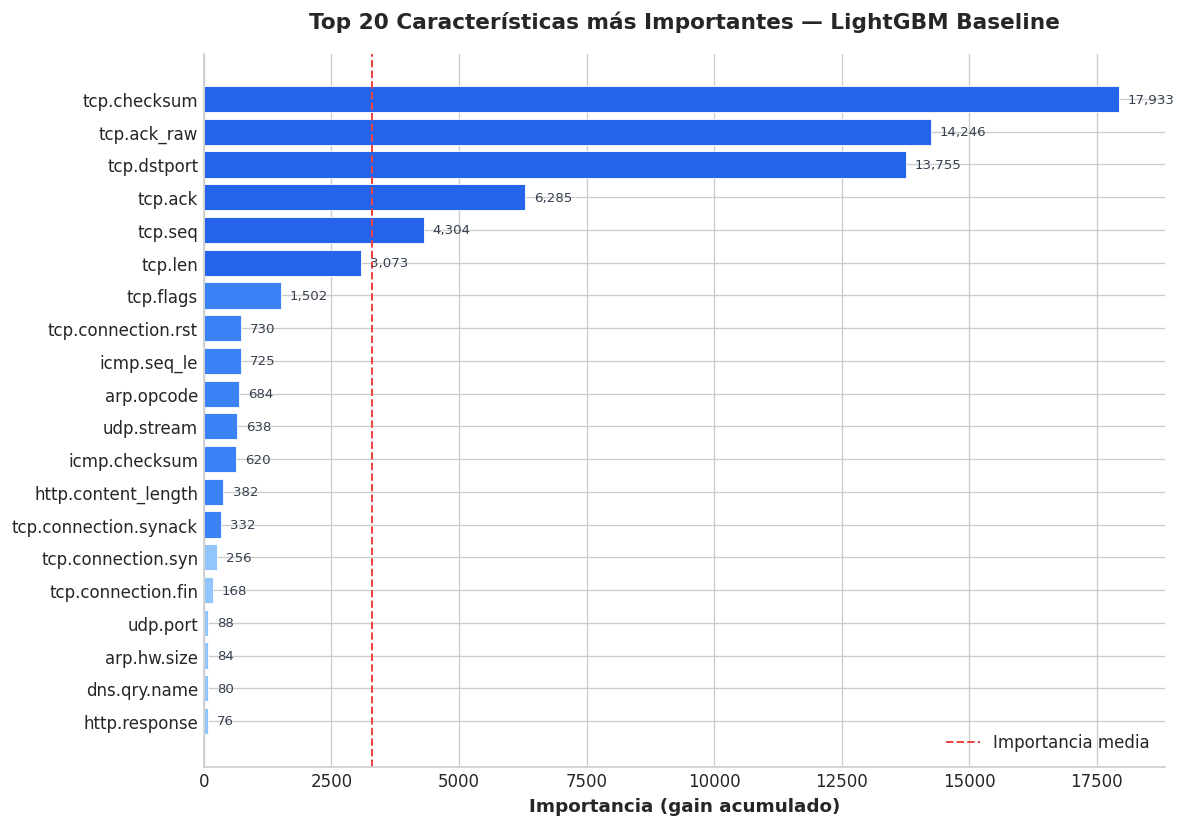

In [9]:
# =============================================================================
# ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS
# Basado en el modelo baseline
# =============================================================================

# --- Extraer importancias ---
importances = model_base.feature_importances_
feat_importance_df = pd.DataFrame({
    "Feature"   : feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).reset_index(drop=True)

top_k = CONFIG["pruning_top_k"]
top_features = feat_importance_df["Feature"].head(top_k).tolist()

# --- Gráfico de importancia ---
fig, ax = plt.subplots(figsize=(10, max(5, top_k * 0.35)))

top_df = feat_importance_df.head(top_k).iloc[::-1]
colors = ["#2563EB" if i < top_k * 0.3 else
          "#3B82F6" if i < top_k * 0.7 else
          "#93C5FD" for i in range(len(top_df))]

bars = ax.barh(top_df["Feature"], top_df["Importance"],
               color=colors[::-1], edgecolor="white", linewidth=0.5)

# Anotaciones de valor
for bar, val in zip(bars, top_df["Importance"]):
    ax.text(bar.get_width() + max(top_df["Importance"]) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", fontsize=8, color="#374151")

ax.set_xlabel("Importancia (gain acumulado)", fontweight="bold")
ax.set_title(f"Top {top_k} Características más Importantes — LightGBM Baseline",
             fontweight="bold", pad=15)
ax.axvline(top_df["Importance"].mean(), color="#EF4444",
           linestyle="--", linewidth=1.2, label="Importancia media")
ax.legend(loc="lower right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["output_dir"], "feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Optimización mediante Pruning

El **pruning** en modelos de árbol de decisión (como LightGBM) se implementa como una **selección de características por importancia**. Este enfoque:

1. Entrena el modelo completo y extrae la importancia de cada feature.
2. Conserva únicamente las top-K características más importantes.
3. Re-entrena el modelo con el subconjunto reducido de features.

En el contexto de edge computing IoT, reducir los requerimientos de procesamiento, memoria y tiempo de inferencia en dispositivos de borde.

In [10]:
# =============================================================================
# MODELO 2: PRUNING — Selección por importancia de características
# =============================================================================

print(f"Aplicando Pruning: conservando el top {CONFIG['pruning_top_k']} características más importantes...")

# --- Índices de las top-K features ---
top_feature_indices = [
    feature_names.index(f) for f in top_features
]

# --- Subconjuntos de datos reducidos ---
X_train_pruned = X_train[:, top_feature_indices]
X_test_pruned  = X_test[:, top_feature_indices]

print(f"Features originales: {X_train.shape[1]}")
print(f"Features tras pruning: {X_train_pruned.shape[1]}")
print(f"Reducción: {(1 - X_train_pruned.shape[1]/X_train.shape[1])*100:.1f}%")

# --- Entrenamiento del modelo podado ---
t_start = time.perf_counter()

model_pruned = lgb.LGBMClassifier(**CONFIG["lgbm_params"])
model_pruned.fit(
    X_train_pruned, y_train,
    eval_set=[(X_test_pruned, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False),
               lgb.log_evaluation(period=-1)]
)

t_train = time.perf_counter() - t_start
print(f"\nEntrenamiento completado en {t_train:.2f}s")

# --- Evaluación ---
save_path_pruned = os.path.join(CONFIG["output_dir"], "model_pruned.pkl")

metrics_pruned = evaluate_model(
    model=model_pruned,
    X_test=X_test_pruned,
    y_test=y_test,
    model_name="Pruning",
    save_path=save_path_pruned,
    n_latency_samples=CONFIG["latency_samples"],
    latency_repeats=CONFIG["latency_repeats"]
)

results.append(metrics_pruned)

# Guardar metadatos del pruning
pruning_metadata = {
    "top_k": CONFIG["pruning_top_k"],
    "selected_features": top_features,
    "feature_indices": top_feature_indices
}
joblib.dump(pruning_metadata, os.path.join(CONFIG["output_dir"], "pruning_metadata.pkl"))
print("\nMetadatos de pruning guardados.")

Aplicando Pruning: conservando el top 20 características más importantes...
Features originales: 42
Features tras pruning: 20
Reducción: 52.4%

Entrenamiento completado en 38.45s

Evaluando: Pruning
Accuracy: 0.9267
Precision: 0.9366
Recall: 0.9267
F1-Score: 0.9290
Latencia: 94.57 ms (sobre 1000 muestras)
RAM usada: 581.09 MB
Tamaño: 6984.43 KB
Guardado en: ./output_models/model_pruned.pkl

Metadatos de pruning guardados.


## 9. Optimización mediante Compresión Ligera

La compresión ligera aplicada mediante Joblib permite reducir principalmente el tamaño de almacenamiento del modelo serializado, facilitando su despliegue en dispositivos de borde con recursos limitados.

Las variaciones observadas en la latencia pueden verse influenciadas por el entorno experimental de Google Colab y no necesariamente representan una mejora directa en el tiempo de inferencia del modelo cargado en memoria.

### Implementación práctica
1. Se utiliza el modelo LightGBM previamente entrenado.
2. El modelo se serializa utilizando compresión de archivos.
3. Se mide el tamaño final del archivo comprimido.
4. Se evalúa el impacto sobre:
- Accuracy
- Precision
- Recall
- F1-Score
- Latencia de inferencia
- RAM utilizada por el proceso experimental en Google Colab
- Tamaño del modelo serializado

Esta estrategia representa una alternativa práctica y eficiente para escenarios IoT edge, donde el almacenamiento y los recursos computacionales son limitados.

In [11]:
# =============================================================================
# MÓDULO DE COMPRESIÓN LIGERA
# =============================================================================

def compress_model(model, save_path: str, compression_level=CONFIG["compression_level"]) -> float:
    """
    Serializa y comprime un modelo utilizando Joblib.

    Args:
        model: Modelo entrenado.
        save_path: Ruta donde se guardará el modelo comprimido.
        compression_level: Nivel de compresión de Joblib, entre 0 y 9.

    Returns:
        Tamaño del modelo comprimido en KB.
    """
    joblib.dump(model, save_path, compress=compression_level)
    size_kb = os.path.getsize(save_path) / 1024
    return size_kb


print("Módulo de compresión ligera definido correctamente.")

Módulo de compresión ligera definido correctamente.


In [12]:
# =============================================================================
# MODELO 3: COMPRESIÓN LIGERA DEL MODELO BASE
# =============================================================================

print("Aplicando compresión ligera del modelo base...")

save_path_compressed = os.path.join(
    CONFIG["output_dir"],
    "model_base_compressed.pkl"
)

# Guardar modelo base con compresión alta
compressed_size_kb = compress_model(
    model=model_base,
    save_path=save_path_compressed,
    compression_level=9
)

# Evaluar el mismo modelo base
metrics_compressed = evaluate_model(
    model=model_base,
    X_test=X_test,
    y_test=y_test,
    model_name="Compresión ligera",
    save_path=os.path.join(CONFIG["output_dir"], "temp_compressed_eval.pkl"),
    n_latency_samples=CONFIG["latency_samples"],
    latency_repeats=CONFIG["latency_repeats"]
)

# Reemplazar el tamaño por el tamaño real comprimido
metrics_compressed["Tamaño_KB"] = round(compressed_size_kb, 2)

print(f"Tamaño comprimido real: {compressed_size_kb:.2f} KB")

results.append(metrics_compressed)

Aplicando compresión ligera del modelo base...

Evaluando: Compresión ligera
Accuracy: 0.9260
Precision: 0.9357
Recall: 0.9260
F1-Score: 0.9282
Latencia: 108.71 ms (sobre 1000 muestras)
RAM usada: 609.25 MB
Tamaño: 7230.03 KB
Guardado en: ./output_models/temp_compressed_eval.pkl
Tamaño comprimido real: 2922.04 KB


## 10. Optimización Combinada: Pruning + Compresión Ligera

Esta sección implementa una estrategia de co-optimización, combinando técnicas de reducción de características y compresión ligera del modelo.

### Estrategia aplicada

1. **Pruning:** El modelo se re-entrena utilizando únicamente las características más importantes obtenidas del análisis de importancia del modelo base.
2. **Compresión ligera:** El modelo podado se serializa utilizando compresión de archivos para reducir su tamaño de almacenamiento.

La combinación de ambas técnicas permite obtener un modelo más liviano y eficiente para dispositivos de borde, reduciendo el tamaño del modelo y manteniendo un desempeño predictivo similar en las métricas de clasificación.

In [13]:
# =============================================================================
# MODELO 4: PRUNING + COMPRESIÓN LIGERA
# =============================================================================

print("Aplicando Pruning + Compresión ligera...")

save_path_pq = os.path.join(
    CONFIG["output_dir"], "model_pruned_compressed.pkl"
)

# Guardar modelo podado con compresión alta
joblib.dump(model_pruned, save_path_pq, compress=CONFIG["compression_level"])

# Evaluar modelo podado
metrics_pq = evaluate_model(
    model=model_pruned,
    X_test=X_test_pruned,
    y_test=y_test,
    model_name="Pruning + Compresión ligera",
    save_path=os.path.join(CONFIG["output_dir"], "temp_pq_eval.pkl"),
    n_latency_samples=CONFIG["latency_samples"],
    latency_repeats=CONFIG["latency_repeats"]
)

compressed_pq_size_kb = os.path.getsize(save_path_pq) / 1024

metrics_pq["Tamaño_KB"] = round(compressed_pq_size_kb, 2)

print(f"Tamaño comprimido real: {compressed_pq_size_kb:.2f} KB")

results.append(metrics_pq)

Aplicando Pruning + Compresión ligera...

Evaluando: Pruning + Compresión ligera
Accuracy: 0.9267
Precision: 0.9366
Recall: 0.9267
F1-Score: 0.9290
Latencia: 89.23 ms (sobre 1000 muestras)
RAM usada: 609.31 MB
Tamaño: 6984.43 KB
Guardado en: ./output_models/temp_pq_eval.pkl
Tamaño comprimido real: 2840.76 KB


## 11. Tabla Comparativa

Consolidación de los resultados experimentales obtenidos para los cuatro escenarios evaluados: modelo base, pruning, compresión ligera y pruning con compresión ligera.

La comparación permite analizar el equilibrio entre eficacia predictiva y eficiencia computacional, considerando métricas de clasificación, latencia de inferencia, tamaño del modelo serializado y RAM utilizada por el proceso experimental en Google Colab.

In [14]:
# =============================================================================
# TABLA COMPARATIVA
# =============================================================================

df_results = pd.DataFrame(results)

# --- Calcular reducción relativa respecto al baseline ---
baseline_row = df_results[df_results["Modelo"] == "Baseline"].iloc[0]

df_display = df_results.copy()
df_display["F1_vs_Base"] = ((df_display["F1-Score"] - baseline_row["F1-Score"])
                             / baseline_row["F1-Score"] * 100).round(2)
df_display["Lat_vs_Base"] = ((df_display["Latencia_ms"] - baseline_row["Latencia_ms"])
                              / baseline_row["Latencia_ms"] * 100).round(2)
df_display["Tam_vs_Base"] = ((df_display["Tamaño_KB"] - baseline_row["Tamaño_KB"])
                              / baseline_row["Tamaño_KB"] * 100).round(2)

# --- Mostrar tabla principal ---
print("=" * 100)
print(" TABLA COMPARATIVA FINAL — Pipeline de Optimización LightGBM para IoT Edge")
print("=" * 100)

cols_main = ["Modelo", "Accuracy", "Precision", "Recall", "F1-Score",
             "Latencia_ms", "RAM_Proceso_Colab_MB", "Tamaño_KB"]
print(df_results[cols_main].to_string(index=False))

print("\n" + "=" * 100)
print(" VARIACIÓN RELATIVA RESPECTO AL BASELINE (%)")
print("=" * 100)
cols_delta = ["Modelo", "F1_vs_Base", "Lat_vs_Base", "Tam_vs_Base"]
print(df_display[cols_delta].to_string(index=False))
print(" (negativo en F1 = pérdida; negativo en Latencia/Tamaño = mejora)")
print("=" * 100)

 TABLA COMPARATIVA FINAL — Pipeline de Optimización LightGBM para IoT Edge
                     Modelo  Accuracy  Precision  Recall  F1-Score  Latencia_ms  RAM_Proceso_Colab_MB  Tamaño_KB
                   Baseline    0.9260     0.9357  0.9260    0.9282       117.22                599.33    7230.03
                    Pruning    0.9267     0.9366  0.9267    0.9290        94.57                581.09    6984.43
          Compresión ligera    0.9260     0.9357  0.9260    0.9282       108.71                609.25    2922.04
Pruning + Compresión ligera    0.9267     0.9366  0.9267    0.9290        89.23                609.31    2840.76

 VARIACIÓN RELATIVA RESPECTO AL BASELINE (%)
                     Modelo  F1_vs_Base  Lat_vs_Base  Tam_vs_Base
                   Baseline        0.00         0.00         0.00
                    Pruning        0.09       -19.32        -3.40
          Compresión ligera        0.00        -7.26       -59.58
Pruning + Compresión ligera        0.09       -23.

## 12. Visualizaciones Comparativas

Dashboard de visualizaciones para análisis del trade-off entre calidad del modelo y eficiencia computacional. Incluye:
- Accuracy y F1-Score comparativos
- Latencia de inferencia
- Tamaño del modelo serializado

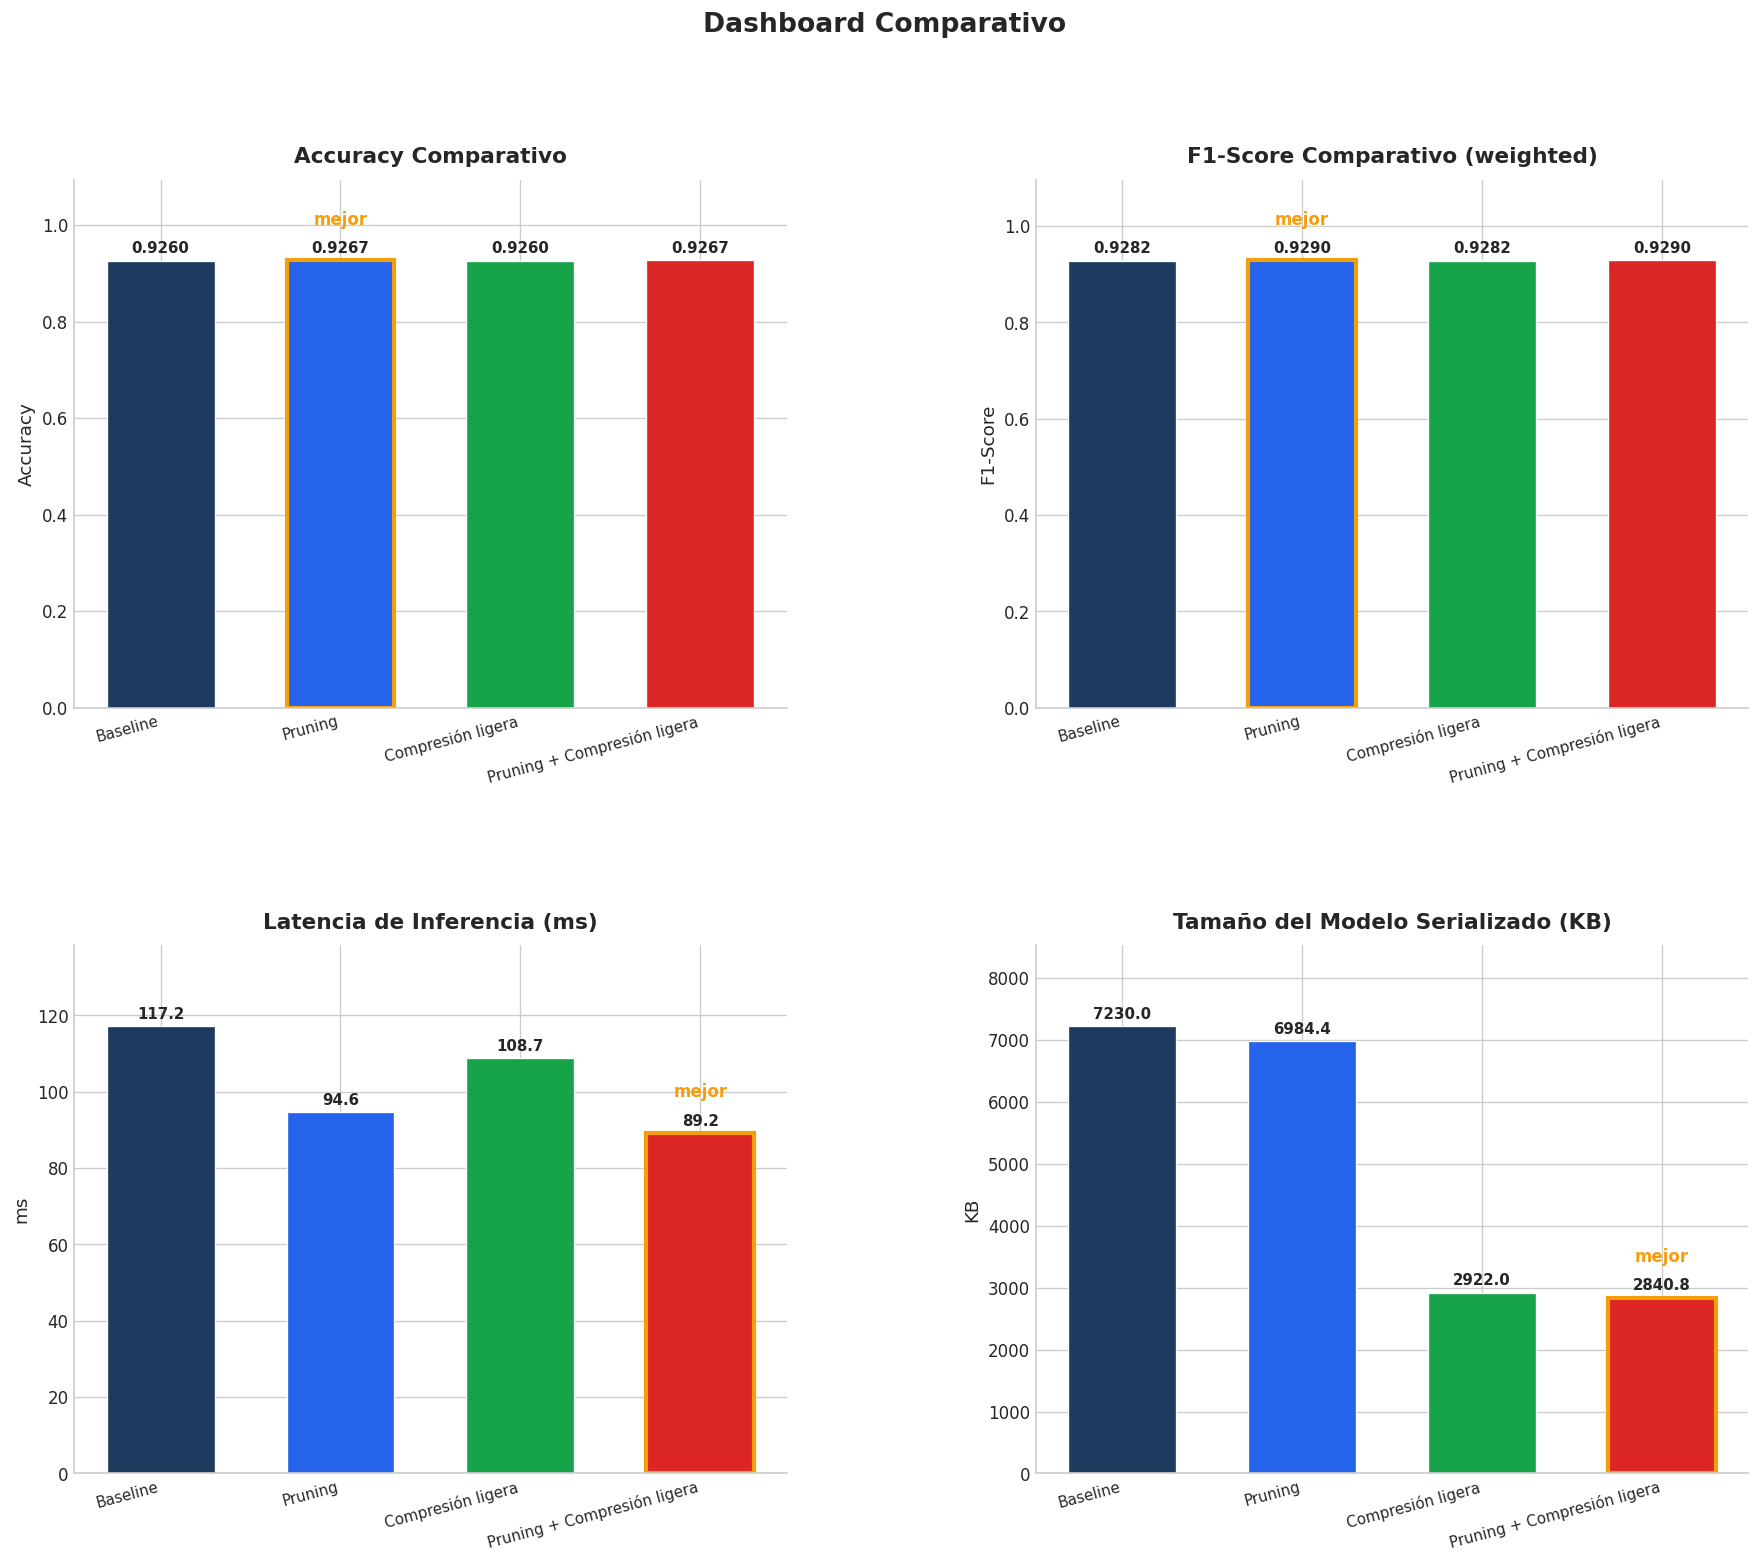

Dashboard guardado.


In [18]:
# =============================================================================
# DASHBOARD DE VISUALIZACIONES COMPARATIVAS
# =============================================================================

# --- Paleta de colores por modelo ---
MODEL_COLORS = {
    "Baseline": "#1E3A5F",
    "Pruning": "#2563EB",
    "Compresión ligera": "#16A34A",
    "Pruning + Compresión ligera": "#DC2626",
}

model_labels = df_results["Modelo"].tolist()
bar_colors = [MODEL_COLORS.get(m, "#6B7280") for m in model_labels]

# ─────────────────────────────────────────────────────────────────────────────
# FIGURA 1: Dashboard de métricas principales (2×2)
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Dashboard Comparativo",
    fontsize=16, fontweight="bold", y=0.98
)
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Subplots de barras ──
metrics_config = [
    (gs[0, 0], "Accuracy", "Accuracy Comparativo", True, "Accuracy"),
    (gs[0, 1], "F1-Score", "F1-Score Comparativo (weighted)", True, "F1-Score"),
    (gs[1, 0], "Latencia_ms", "Latencia de Inferencia (ms)", False, "ms"),
    (gs[1, 1], "Tamaño_KB", "Tamaño del Modelo Serializado (KB)", False, "KB"),
]

for spec, col, title, higher_better, unit in metrics_config:
    ax = fig.add_subplot(spec)
    vals = df_results[col].values

    bars = ax.bar(model_labels, vals, color=bar_colors,
                  edgecolor="white", linewidth=0.8, width=0.6)

    # Destacar mejor valor
    best_idx = np.argmax(vals) if higher_better else np.argmin(vals)
    bars[best_idx].set_edgecolor("#F59E0B")
    bars[best_idx].set_linewidth(2.5)

    # Etiquetas de valor
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(vals) * 0.01,
            f"{val:.4f}" if unit in ["Accuracy", "F1-Score"] else f"{val:.1f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    ax.set_title(title, fontweight="bold", pad=10)
    ax.set_ylabel(unit)
    ax.set_ylim(0, max(vals) * 1.18)
    ax.set_xticklabels(model_labels, rotation=15, ha="right", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Indicar el mejor
    ax.text(
        best_idx, vals[best_idx] + max(vals) * 0.08,
        "mejor", ha="center", fontsize=10, fontweight="bold", color="#F59E0B"
    )

plt.savefig(
    os.path.join(CONFIG["output_dir"], "dashboard_comparativo.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Dashboard guardado.")

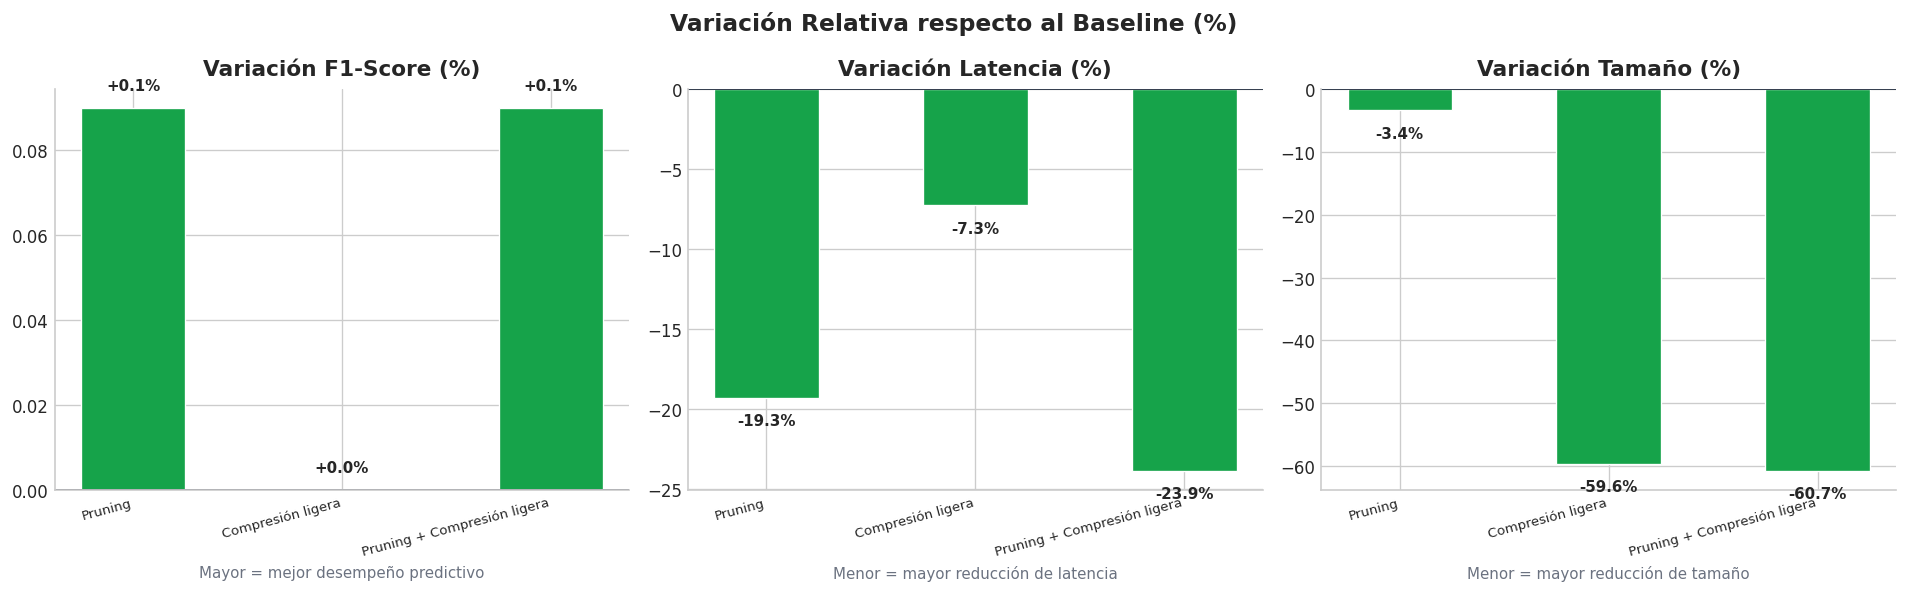

Gráfico de reducción relativa guardado.


In [19]:
# =============================================================================
# FIGURA 2: Comparativa de reducción relativa al baseline
# =============================================================================

# Excluir baseline de la comparación relativa
df_delta = df_display[df_display["Modelo"] != "Baseline"].copy()

fig3, axes3 = plt.subplots(1, 3, figsize=(16, 5))
fig3.suptitle(
    "Variación Relativa respecto al Baseline (%)",
    fontsize=14, fontweight="bold"
)

delta_metrics = [
    ("F1_vs_Base", "Variación F1-Score (%)", True, "Mayor = mejor desempeño predictivo"),
    ("Lat_vs_Base", "Variación Latencia (%)", False, "Menor = mayor reducción de latencia"),
    ("Tam_vs_Base", "Variación Tamaño (%)", False, "Menor = mayor reducción de tamaño"),
]

for ax, (col, ylabel, higher_better, subtitle) in zip(axes3, delta_metrics):
    vals = df_delta[col].values
    models = df_delta["Modelo"].values
    colors_delta = ["#16A34A" if (v > 0 and higher_better) or (v < 0 and not higher_better)
                    else "#DC2626" for v in vals]

    bars = ax.bar(models, vals, color=colors_delta,
                  edgecolor="white", linewidth=0.8, width=0.5)
    ax.axhline(0, color="#374151", linewidth=1.2, linestyle="-")

    for bar, val in zip(bars, vals):
        y_pos = bar.get_height() + (max(abs(vals)) * 0.04) if val >= 0 else \
                bar.get_height() - (max(abs(vals)) * 0.08)
        ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                f"{val:+.1f}%", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

    ax.set_title(ylabel, fontweight="bold", pad=8)
    ax.set_xlabel(subtitle, fontsize=9, color="#6B7280")
    ax.set_xticklabels(models, rotation=15, ha="right", fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(
    os.path.join(CONFIG["output_dir"], "reduccion_relativa_baseline.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Gráfico de reducción relativa guardado.")

## 13. Exportación Final de Artefactos

Exportación consolidada de todos los modelos, metadatos y resultados para:
- Reproducibilidad del experimento
- Preparación para posibles pipelines de despliegue
- Documentación académica

In [20]:
# =============================================================================
# EXPORTACIÓN FINAL DE ARTEFACTOS
# =============================================================================

# --- 1. Tabla comparativa (CSV) ---
final_csv = os.path.join(CONFIG["output_dir"], "comparison_results_final.csv")
df_display.to_csv(final_csv, index=False, encoding="utf-8")
print(f"Tabla de resultados: {final_csv}")

# --- 2. Modelos LightGBM base y podado (.pkl) ---
# (Ya guardados durante evaluación — verificar)
for path in [save_path_base, save_path_pruned, save_path_compressed, save_path_pq]:
    if os.path.exists(path):
        print(f"Modelo verificado: {path}")
    else:
        print(f"Modelo no encontrado: {path}")

# --- 3. Metadatos del experimento ---
experiment_meta = {
    "proyecto": "Optimización mediante Pruning y Compresión ligera para la Ejecución Eficiente de Modelos de IA en Dispositivos de Borde para Entornos IoT con Recursos Limitados",
    "año": 2026,
    "dataset": CONFIG["dataset_path"],
    "target": CONFIG["target_col"],
    "n_clases": int(n_classes),
    "n_features_orig": int(X_train.shape[1]),
    "n_features_pruned": int(CONFIG["pruning_top_k"]),
    "pruning_top_k": int(CONFIG["pruning_top_k"]),
    "compression_level": int(CONFIG["compression_level"]),
    "train_samples": int(X_train.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "top_features": top_features,
    "class_mapping": {str(k): v for k, v in class_mapping.items()},
    "lgbm_params": CONFIG["lgbm_params"],
    "resultados": results,
}

meta_path = os.path.join(CONFIG["output_dir"], "experiment_metadata.pkl")
joblib.dump(experiment_meta, meta_path)
print(f"Metadatos del experimento: {meta_path}")

# --- 4. LabelEncoder ---
le_path = os.path.join(CONFIG["output_dir"], "label_encoder.pkl")
joblib.dump(le, le_path)
print(f"LabelEncoder: {le_path}")

# --- Resumen de tamaños finales ---
print(f"\nResumen de tamaños de modelos:")
model_paths = {
    "Baseline": save_path_base,
    "Pruning": save_path_pruned,
    "Compresión Ligera": save_path_compressed,
    "Pruning+Compr": save_path_pq,
}
for name, path in model_paths.items():
    if os.path.exists(path):
        sz = os.path.getsize(path) / 1024
        print(f"{name:<20}: {sz:>8.1f} KB")

print("\nExportación completada.")

Tabla de resultados: ./output_models/comparison_results_final.csv
Modelo verificado: ./output_models/model_base.pkl
Modelo verificado: ./output_models/model_pruned.pkl
Modelo verificado: ./output_models/model_base_compressed.pkl
Modelo verificado: ./output_models/model_pruned_compressed.pkl
Metadatos del experimento: ./output_models/experiment_metadata.pkl
LabelEncoder: ./output_models/label_encoder.pkl

Resumen de tamaños de modelos:
Baseline            :   7230.0 KB
Pruning             :   6984.4 KB
Compresión Ligera   :   2922.0 KB
Pruning+Compr       :   2840.8 KB

Exportación completada.
